# Phase 5 — Batch Size Ablation

NT-Xent treats every other item in the batch as a negative. Shrink the batch
and you shrink the negative pool, which is supposed to hurt contrastive
learning. Test that directly.

bs=256 is the Phase 1 default and gets pulled in from disk. Here we train
bs ∈ {128, 64} with the same tau=0.5 and everything else held fixed. We do
*not* scale learning rate with batch size — the comparison is cleaner when
only one thing changes.

Compute note: bs=64 runs 4× the gradient steps per epoch versus bs=256, so
the epoch budget is reduced to 50 to keep wall-clock manageable. All runs
use the same reduced budget for apples-to-apples.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    get_device, get_cifar_resnet18, get_eval_transform, get_simclr_transform,
    ProjectionHead, SimCLRModel, nt_xent_loss, knn_monitor, SimCLRPairDataset,
)

SMOKE_TEST = False

BATCH_SIZES     = [128, 64]     # bs=256 comes from Phase 1
BASELINE_BS     = 256

cfg = dict(
    ssl_epochs    = 2  if SMOKE_TEST else 50,
    probe_epochs  = 3  if SMOKE_TEST else 50,
    lr            = 3e-4,
    probe_lr      = 1e-3,
    weight_decay  = 1e-6,
    temperature   = 0.5,
    seed          = 42,
    num_workers   = 0,
    data_root     = './data',
    knn_k         = 20,
    knn_interval  = 10,
    ckpt_dir      = 'models/ablation_batchsize' if not SMOKE_TEST else 'models/ablation_batchsize_smoke',
    results_path  = 'results/ablation_batchsize.json' if not SMOKE_TEST else 'results/ablation_batchsize_smoke.json',
    fig_path      = 'figures/ablation_batchsize_curves.png' if not SMOKE_TEST else 'figures/ablation_batchsize_smoke.png',
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])
os.makedirs(cfg['ckpt_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True); os.makedirs('figures', exist_ok=True)

device = get_device()
print('Device:', device)
print('Batch sizes to train:', BATCH_SIZES, f' (baseline bs={BASELINE_BS} reused from Phase 1)')
print('Config:', cfg)


Device: privateuseone:0
Batch sizes to train: [128, 64]  (baseline bs=256 reused from Phase 1)
Config: {'ssl_epochs': 50, 'probe_epochs': 50, 'lr': 0.0003, 'probe_lr': 0.001, 'weight_decay': 1e-06, 'temperature': 0.5, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'knn_k': 20, 'knn_interval': 10, 'ckpt_dir': 'models/ablation_batchsize', 'results_path': 'results/ablation_batchsize.json', 'fig_path': 'figures/ablation_batchsize_curves.png'}


In [2]:
# --- Cell 2: Data ---
ssl_transform  = get_simclr_transform(32)
eval_transform = get_eval_transform(32)

pair_ds       = SimCLRPairDataset(CIFAR10(cfg['data_root'], train=True, download=True, transform=None),
                                  transform=ssl_transform)
train_eval_ds = CIFAR10(cfg['data_root'], train=True,  download=True, transform=eval_transform)
test_ds       = CIFAR10(cfg['data_root'], train=False, download=True, transform=eval_transform)

memory_loader = DataLoader(train_eval_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)
test_loader   = DataLoader(test_ds, batch_size=512, shuffle=False,
                           num_workers=cfg['num_workers'], pin_memory=False)

def make_ssl_loader(bs: int):
    return DataLoader(pair_ds, batch_size=bs, shuffle=True,
                      num_workers=cfg['num_workers'], pin_memory=False, drop_last=True)

probe_train_loader = DataLoader(train_eval_ds, batch_size=256,
                                shuffle=True, num_workers=cfg['num_workers'],
                                pin_memory=False, drop_last=False)
print('data ready.')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
data ready.


In [3]:
# --- Cell 3: Train one SimCLR at a given batch size (resumable) ---
def _ckpt_path(bs: int) -> str:
    return os.path.join(cfg['ckpt_dir'], f'simclr_bs_{bs}.pth')

def train_simclr_at_bs(bs: int) -> dict:
    ckpt_path = _ckpt_path(bs)
    ssl_loader = make_ssl_loader(bs)
    torch.manual_seed(cfg['seed'])
    model = SimCLRModel(get_cifar_resnet18(), hidden_dim=512, proj_dim=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'loss': [], 'knn_epoch': [], 'knn_acc': [], 'epoch_sec': []}
    start_epoch = 1

    if os.path.exists(ckpt_path):
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        model.load_state_dict(ck['model_state']); model.to(device)
        optimizer.load_state_dict(ck['optimizer_state'])
        log = ck['log']; start_epoch = ck['epoch'] + 1
        print(f'  [bs={bs}] RESUMING from epoch {start_epoch}', flush=True)
    else:
        print(f'  [bs={bs}] starting fresh', flush=True)

    for epoch in range(start_epoch, cfg['ssl_epochs']+1):
        model.train()
        t0 = time.time()
        loss_sum = n_batches = 0
        pbar = tqdm(ssl_loader, desc=f'bs={bs} ep {epoch}/{cfg["ssl_epochs"]}', leave=False)
        for v1, v2, _ in pbar:
            v1 = v1.to(device); v2 = v2.to(device)
            x = torch.cat([v1, v2], dim=0)
            _, z = model(x)
            z = F.normalize(z, dim=1)
            loss = nt_xent_loss(z, temperature=cfg['temperature'])
            optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            loss_sum += float(loss.detach().cpu()); n_batches += 1
        avg_loss = loss_sum/max(n_batches,1); dt = time.time()-t0
        log['epoch'].append(epoch); log['loss'].append(avg_loss); log['epoch_sec'].append(dt)

        if epoch == 1 or epoch % cfg['knn_interval'] == 0 or epoch == cfg['ssl_epochs']:
            acc = knn_monitor(model.backbone, memory_loader, test_loader, device=device, k=cfg['knn_k'])
            log['knn_epoch'].append(epoch); log['knn_acc'].append(acc)
            print(f'    [bs={bs}] ep {epoch:3d}  loss={avg_loss:.4f}  knn={acc*100:.2f}%  ({dt:.1f}s)', flush=True)

        tmp = ckpt_path + '.tmp'
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'log': log, 'bs': bs}, tmp)
        os.replace(tmp, ckpt_path)

    return {'ckpt_path': ckpt_path, 'log': log}

print('training routine ready.')


training routine ready.


In [4]:
# --- Cell 4: Train all non-baseline batch sizes ---
t_all = time.time()
runs = {}
for bs in BATCH_SIZES:
    print(f'>>> SSL run  bs={bs}', flush=True)
    t0 = time.time()
    r = train_simclr_at_bs(bs)
    runs[bs] = r
    print(f'    done in {(time.time()-t0)/60:.1f} min', flush=True)
print(f'\nall SSL runs done in {(time.time()-t_all)/60:.1f} min')


>>> SSL run  bs=128
  [bs=128] starting fresh


bs=128 ep 1/50:   0%|          | 0/390 [00:00<?, ?it/s]

c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


    [bs=128] ep   1  loss=4.5398  knn=44.55%  (114.2s)


bs=128 ep 2/50:   0%|          | 0/390 [00:00<?, ?it/s]

...

bs=64 ep 47/50:   0%|          | 0/781 [00:00<?, ?it/s]

bs=64 ep 48/50:   0%|          | 0/781 [00:00<?, ?it/s]

bs=64 ep 49/50:   0%|          | 0/781 [00:00<?, ?it/s]

bs=64 ep 50/50:   0%|          | 0/781 [00:00<?, ?it/s]

    [bs=64] ep  50  loss=3.2082  knn=76.60%  (131.0s)
    done in 111.1 min

all SSL runs done in 205.8 min


In [5]:
# --- Cell 5: Linear probe on each backbone (fixed protocol) ---
@torch.no_grad()
def _eval_clf(backbone, clf):
    backbone.eval(); clf.eval()
    corr = tot = 0
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = clf(backbone(x)).argmax(1)
        corr += (pred==y).sum().item(); tot += y.size(0)
    return corr/tot

def probe(backbone, epochs: int) -> dict:
    backbone.eval()
    for p in backbone.parameters(): p.requires_grad = False
    torch.manual_seed(cfg['seed'])
    clf = nn.Linear(512, 10).to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=cfg['probe_lr'], weight_decay=cfg['weight_decay'])
    log = {'epoch': [], 'train_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(1, epochs+1):
        clf.train(); ls = corr = tot = 0
        for x, y in probe_train_loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad(): h = backbone(x)
            logits = clf(h); loss = F.cross_entropy(logits, y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            ls += float(loss.detach().cpu())*y.size(0)
            corr += (logits.argmax(1)==y).sum().item(); tot += y.size(0)
        log['epoch'].append(epoch); log['train_loss'].append(ls/tot)
        log['train_acc'].append(corr/tot); log['test_acc'].append(_eval_clf(backbone, clf))
    return {'final_test_acc': log['test_acc'][-1],
            'best_test_acc': max(log['test_acc']),
            'curve': log}

print('probe routine ready.')


probe routine ready.


In [6]:
# --- Cell 6: Probe each + reuse Phase 1 baseline ---
baseline_probe_path = Path('results/simclr_baseline_linear_probe.json')
baseline_result = None
if baseline_probe_path.exists():
    d = json.loads(baseline_probe_path.read_text())
    baseline_result = {
        'final_test_acc': d.get('final_test_acc'),
        'best_test_acc':  d.get('best_test_acc'),
        'curve':          d.get('curve'),
    }
    print(f'Phase 1 baseline (bs={BASELINE_BS}): final={baseline_result["final_test_acc"]*100:.2f}%  best={baseline_result["best_test_acc"]*100:.2f}%')
else:
    print('WARN: Phase 1 probe result not found.')

probe_results = {}
for bs in BATCH_SIZES:
    print(f'>>> probe  bs={bs}', flush=True)
    ck = torch.load(_ckpt_path(bs), map_location='cpu', weights_only=False)
    bb = get_cifar_resnet18().to(device)
    bb_state = {k[len('backbone.'):]: v for k, v in ck['model_state'].items() if k.startswith('backbone.')}
    bb.load_state_dict(bb_state)
    t0 = time.time()
    r = probe(bb, cfg['probe_epochs'])
    probe_results[bs] = r
    print(f'    final={r["final_test_acc"]*100:.2f}%  best={r["best_test_acc"]*100:.2f}%  ({time.time()-t0:.1f}s)', flush=True)

final = {
    'batch_sizes_trained': BATCH_SIZES,
    'baseline_bs':         BASELINE_BS,
    'ssl_epochs':          cfg['ssl_epochs'],
    'probe_epochs':        cfg['probe_epochs'],
    'runs': {str(bs): {'ssl_log': runs[bs]['log'], 'probe': probe_results[bs]} for bs in BATCH_SIZES},
    'baseline': baseline_result,
}
with open(cfg['results_path'], 'w') as f: json.dump(final, f, indent=2)
print('Saved', cfg['results_path'])


Phase 1 baseline (bs=256): final=86.34%  best=86.70%
>>> probe  bs=128
    final=80.93%  best=80.93%  (535.3s)
>>> probe  bs=64
    final=80.55%  best=80.72%  (535.0s)
Saved results/ablation_batchsize.json


Batch size ablation — CIFAR-10 linear probe
    bs     final      best   notes
----------------------------------------------------------
   256    86.34%    86.70%   (Phase 1, 200 ep)
   128    80.93%    80.93%   (50 ep)
    64    80.55%    80.72%   (50 ep)


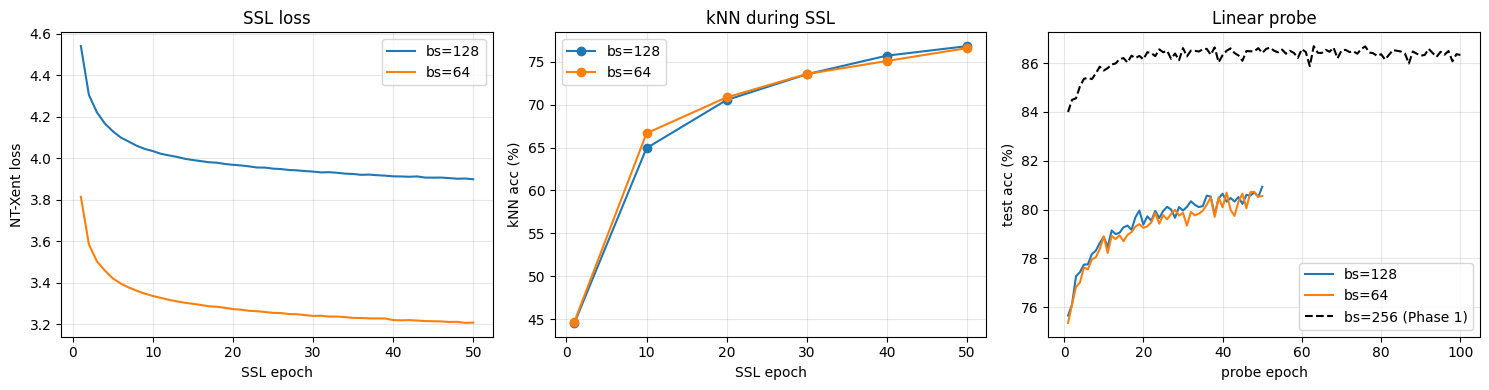

Saved figures/ablation_batchsize_curves.png


In [7]:
# --- Cell 7: Results table + overlay plots ---
def _fmt(x): return f'{x*100:.2f}%' if x is not None else '   n/a '
rows = []
if baseline_result is not None:
    rows.append((BASELINE_BS, baseline_result['final_test_acc'], baseline_result['best_test_acc'], '(Phase 1, 200 ep)'))
for bs in BATCH_SIZES:
    r = probe_results[bs]
    rows.append((bs, r['final_test_acc'], r['best_test_acc'], f"({cfg['ssl_epochs']} ep)"))
rows.sort(key=lambda t: -t[0])

print('Batch size ablation — CIFAR-10 linear probe')
print('=' * 58)
print(f"{'bs':>6}  {'final':>8}  {'best':>8}   notes")
print('-' * 58)
for bs, fi, be, note in rows:
    print(f"{bs:>6}  {_fmt(fi):>8}  {_fmt(be):>8}   {note}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for bs in BATCH_SIZES:
    log = runs[bs]['log']
    axes[0].plot(log['epoch'], log['loss'], label=f'bs={bs}')
axes[0].set_xlabel('SSL epoch'); axes[0].set_ylabel('NT-Xent loss')
axes[0].set_title('SSL loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

for bs in BATCH_SIZES:
    log = runs[bs]['log']
    axes[1].plot(log['knn_epoch'], [a*100 for a in log['knn_acc']], marker='o', label=f'bs={bs}')
axes[1].set_xlabel('SSL epoch'); axes[1].set_ylabel('kNN acc (%)')
axes[1].set_title('kNN during SSL'); axes[1].legend(); axes[1].grid(alpha=0.3)

for bs in BATCH_SIZES:
    c = probe_results[bs]['curve']
    axes[2].plot(c['epoch'], [a*100 for a in c['test_acc']], label=f'bs={bs}')
if baseline_result is not None and baseline_result.get('curve'):
    c = baseline_result['curve']
    axes[2].plot(c['epoch'], [a*100 for a in c['test_acc']],
                 linestyle='--', color='black', label=f'bs={BASELINE_BS} (Phase 1)')
axes[2].set_xlabel('probe epoch'); axes[2].set_ylabel('test acc (%)')
axes[2].set_title('Linear probe'); axes[2].legend(); axes[2].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(cfg['fig_path'], dpi=150)
plt.show()
print('Saved', cfg['fig_path'])
